In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
df = pd.read_csv('C:\\Users\\Anand\\Amzon_Product_review_analysis_problem_4\\Datasets\\Amazon_Product_Review_Cleaned.csv')

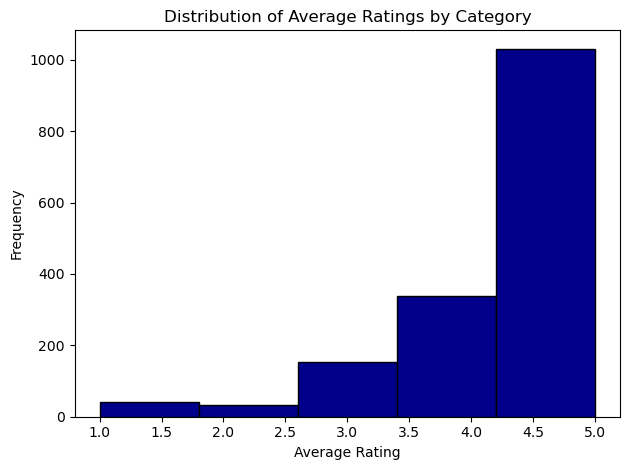

In [12]:
#Histogram to show average ratings by category
cast_avg = df.groupby('primary_category')['reviews.rating'].mean()
plt.hist(df['reviews.rating'], bins=5, color='darkblue', edgecolor='black') 
plt.xlabel('Average Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Average Ratings by Category')
plt.tight_layout() 
plt.show() 

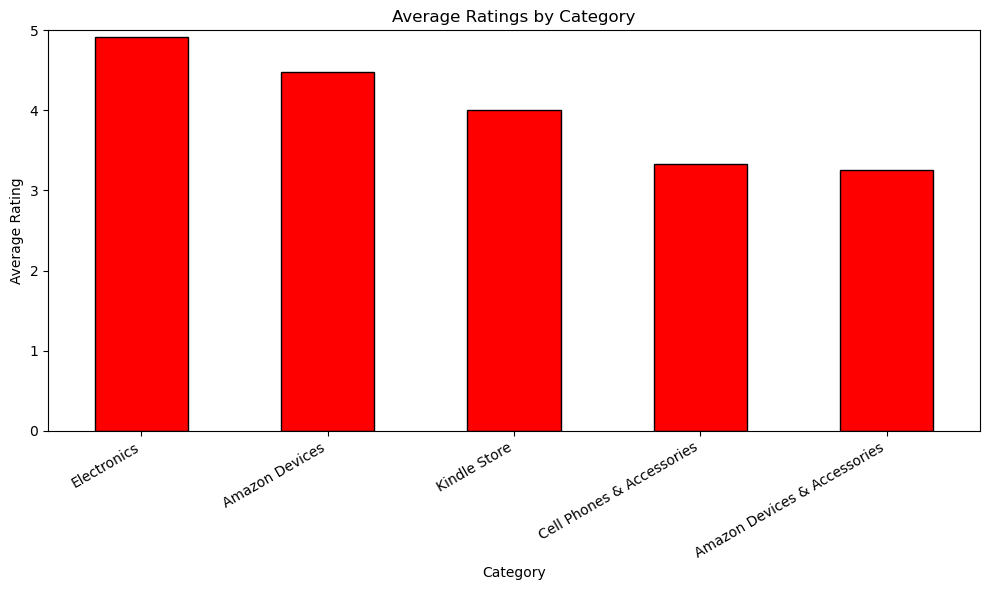

In [11]:
#Bar plot to show average ratings by category
cat_avg = df.groupby('primary_category')['reviews.rating'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
cat_avg.plot(kind='bar', color='red', edgecolor='black')
plt.title('Average Ratings by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 5)
plt.tight_layout()
plt.show() 

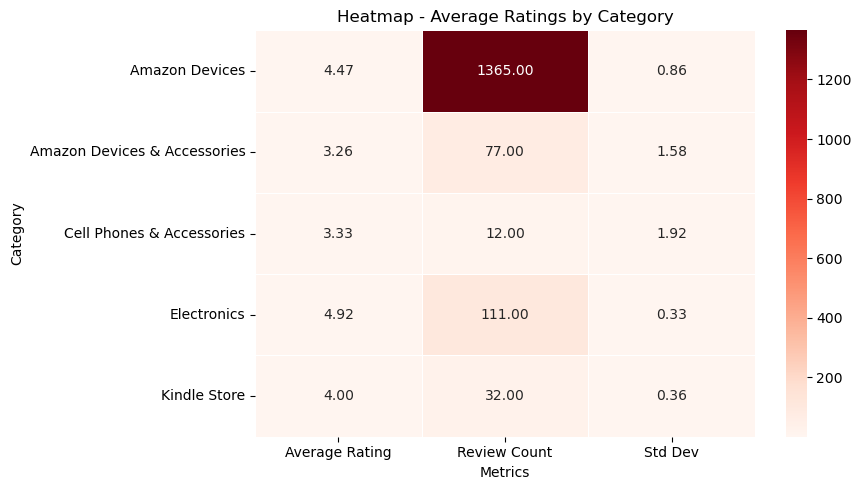

In [ ]:
#Heatmap to show average ratings by category
cat_pivot = df.pivot_table(index="primary_category", values="reviews.rating",aggfunc=["mean", "count", "std"]).fillna(0)

cat_pivot.columns = ["Average Rating", "Review Count", "Std Dev"]

plt.figure(figsize=(9, 5))
sns.heatmap(cat_pivot, annot=True, fmt=".2f", cmap="Reds",linewidths=0.5, linecolor="white", square=False)
plt.title("Heatmap - Average Ratings by Category")
plt.xlabel("Metrics")
plt.ylabel("Category")
plt.tight_layout()
plt.show() 

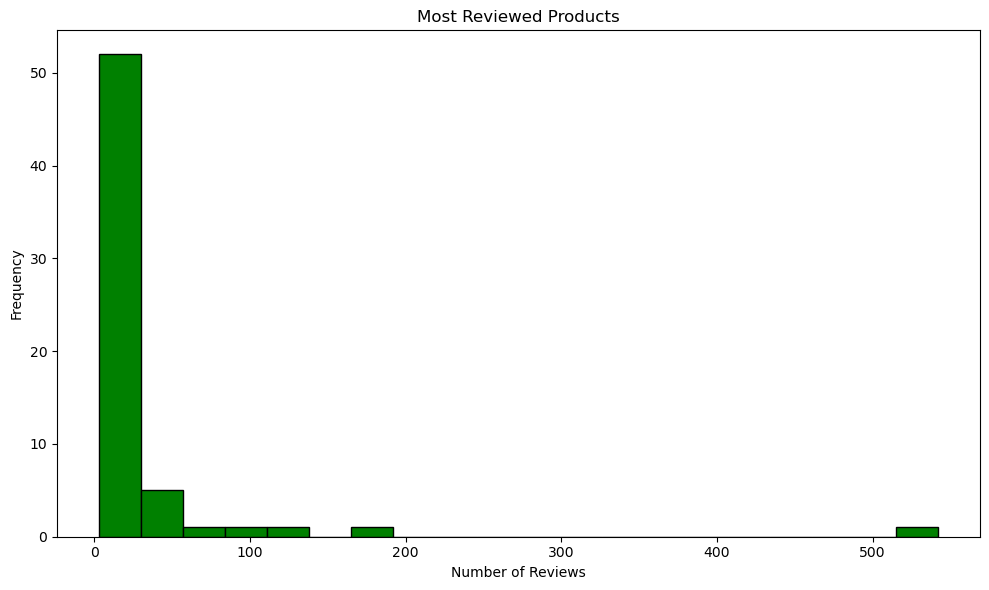

In [17]:
#Histogram to show most reviewed products
top10 = df["name"].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.hist(df['name'].value_counts().values, bins=20, color='green', edgecolor='black')
plt.title('Most Reviewed Products')
plt.xlabel('Number of Reviews')
plt.ylabel('Frequency')
plt.tight_layout() 
plt.show() 

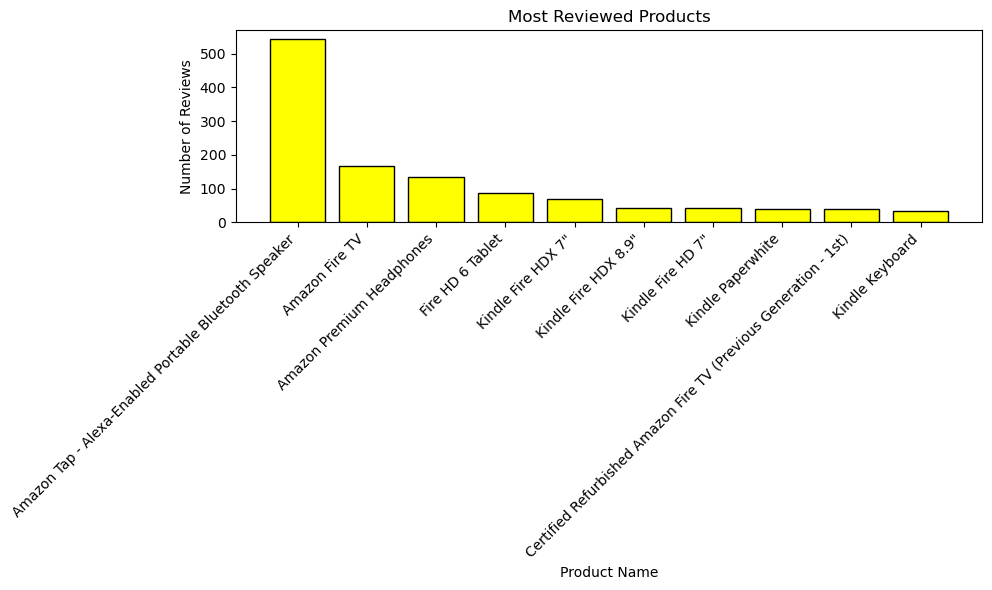

In [19]:
#Bar plot to show most reviewed products
top10 = df["name"].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.bar(top10.index, top10.values, color='yellow', edgecolor='black')
plt.title('Most Reviewed Products')
plt.xlabel('Product Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() 


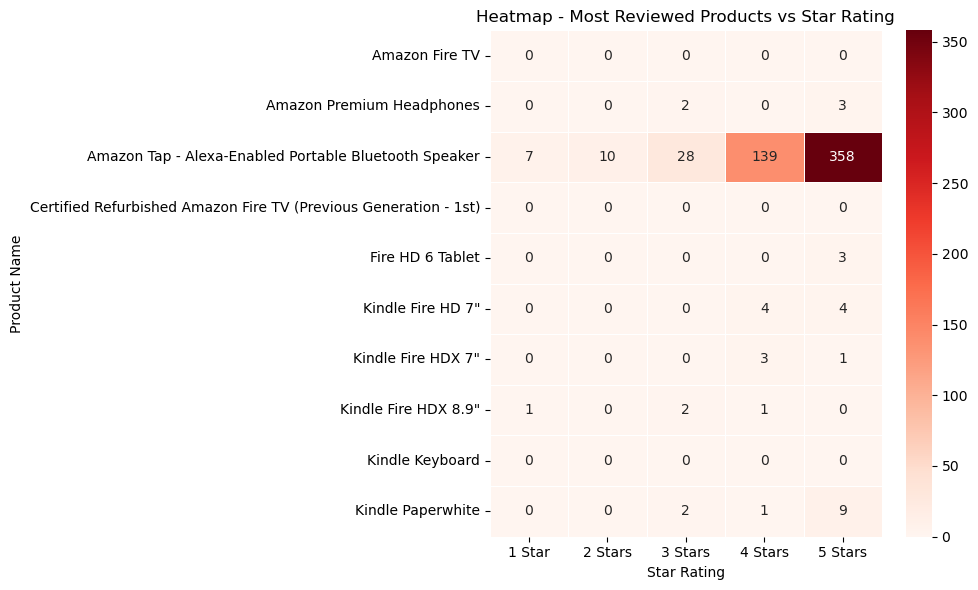

In [30]:
#Heatmap to show most reviewed products
top10_names = df["name"].value_counts().head(10).index
top10_df = df[df["name"].isin(top10_names)]

pivot = top10_df.pivot_table(index="name",columns="reviews.rating",values="reviews.numHelpful",aggfunc="count",fill_value=0)

pivot.columns = ["1 Star", "2 Stars", "3 Stars", "4 Stars", "5 Stars"]

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Reds", linewidths=0.5, linecolor="white", square=False)
plt.title("Heatmap - Most Reviewed Products vs Star Rating")
plt.xlabel("Star Rating")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

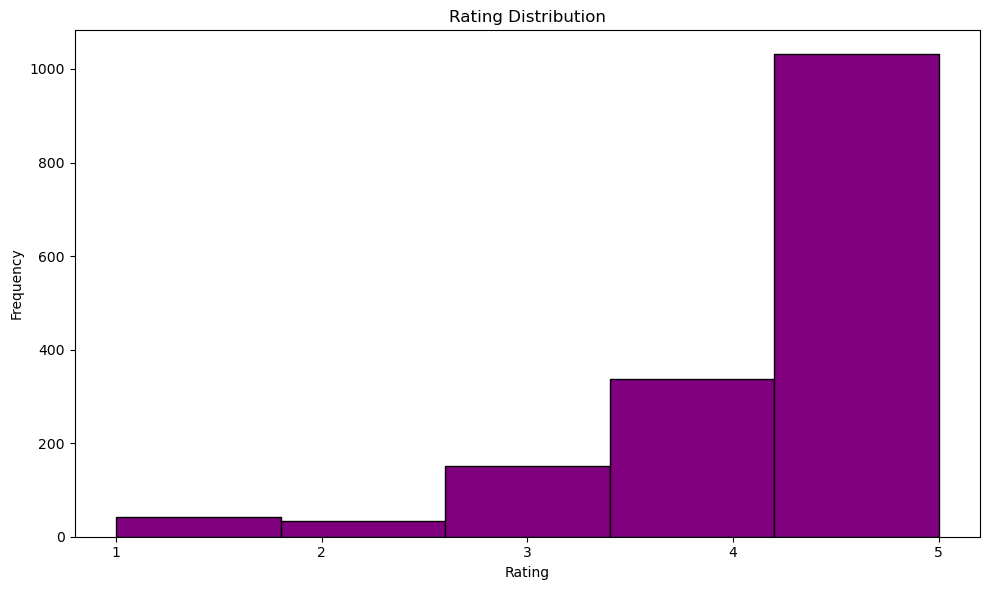

In [22]:
#Histogram to show rating distribution
plt.figure(figsize=(10, 6))
plt.hist(df['reviews.rating'], bins=5, color='purple', edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show() 

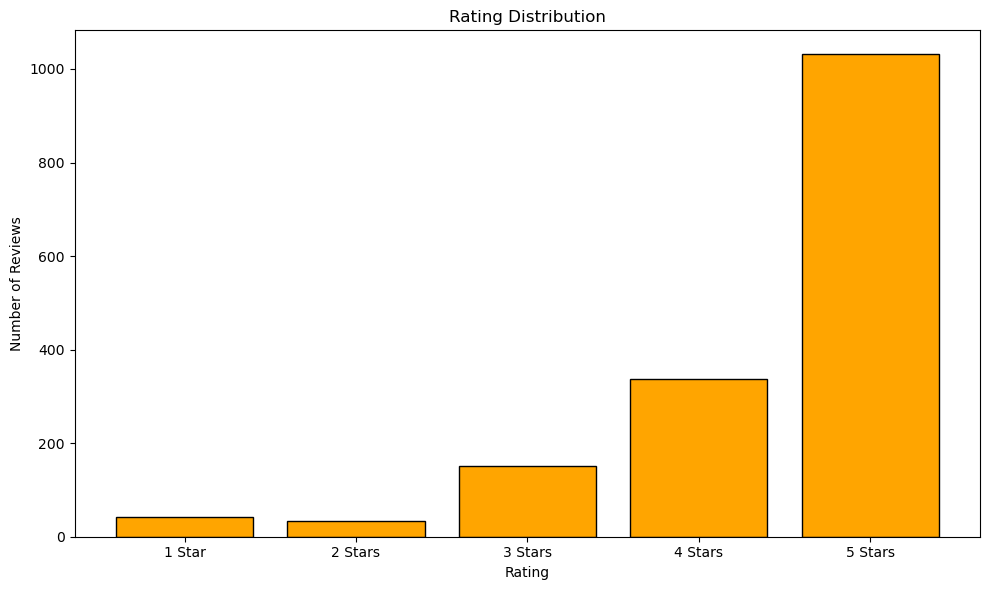

In [35]:
# Bar plot to show rating distribution
rating_counts = df['reviews.rating'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.bar(rating_counts.index, rating_counts.values, color='orange', edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews') 
plt.xticks([1, 2, 3, 4, 5], ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars'], rotation=0)
plt.tight_layout()
plt.show() 

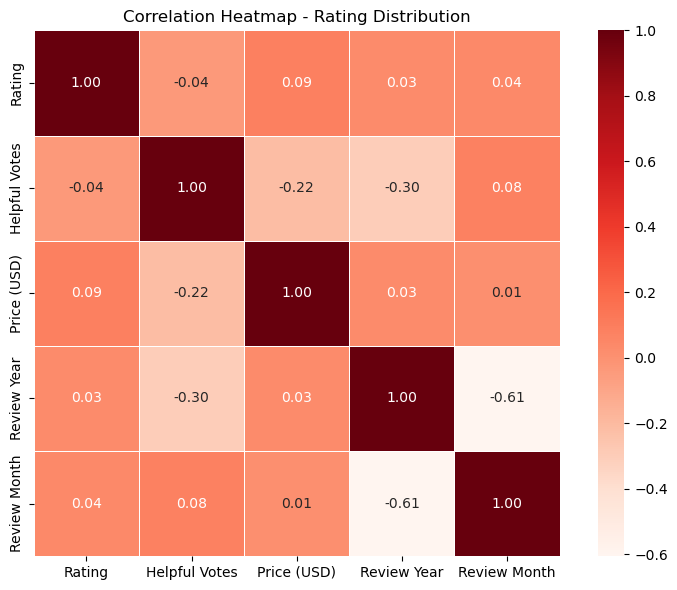

In [ ]:
#Heatmap to show rating distribution
numeric_df = df[["reviews.rating", "reviews.numHelpful", "price_usd", "review_year", "review_month"]].dropna()

numeric_df.columns = ["Rating", "Helpful Votes", "Price (USD)","Review Year", "Review Month"]

corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Reds", linewidths=0.5, linecolor="white", square=True)
plt.title("Correlation Heatmap - Rating Distribution")
plt.tight_layout()
plt.show()
